In [34]:
import numpy as numpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [35]:
x=pd.read_csv(r"C:\Users\shivam parihari\Downloads\train.txt",sep=";",header=None,names=['text','emotion'])

In [36]:
x.head()

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [37]:
x.isnull().sum()

text       0
emotion    0
dtype: int64

In [38]:
u=x['emotion'].unique()
u

array(['sadness', 'anger', 'love', 'surprise', 'fear', 'joy'],
      dtype=object)

In [39]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
x['emotion'] = le.fit_transform(x['emotion'])

In [40]:
x.head()


,text,emotion
0,i didnt feel humiliated,4
1,i can go from feeling so hopeless to so damned...,4
2,im grabbing a minute to post i feel greedy wrong,0
3,i am ever feeling nostalgic about the fireplac...,3
4,i am feeling grouchy,0


In [41]:
x['text']=x['text'].apply(lambda x: x.lower())

In [42]:
import string 
def remove_punctuation(txt):
    return txt.translate(str.maketrans('', '', string.punctuation))

      

In [43]:
x['text']=x['text'].apply(remove_punctuation)

In [44]:
def remove_numbers(txt):
    if txt is None:
        return '' 
    
    new = ''
    for i in txt:
        if not i.isdigit():
            new += i
    return new

x['text'] = x['text'].apply(remove_numbers)



In [45]:
import re

def remove_urls(txt):
    if txt is None:
        return ''
    
    txt = re.sub(r'http\S+|www\.\S+', '', txt)
    return txt

x['text'] = x['text'].apply(remove_urls)


In [46]:
import nltk

In [47]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize 
 

In [48]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to C:\Users\shivam
[nltk_data]     parihari\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [49]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\shivam
[nltk_data]     parihari\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [50]:
stop=set(stopwords.words('english'))
len(stop)

198

In [51]:
x.loc[3]['text']

'i am ever feeling nostalgic about the fireplace i will know that it is still on the property'

In [52]:
def remove(txt):
    words=word_tokenize(txt)
    cleaned=[]
    for word in words:
        if word not in stop:
            cleaned.append(word)
    return ' '.join(cleaned)            

In [53]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')  
nltk.download('omw-1.4')  


[nltk_data] Downloading package stopwords to C:\Users\shivam
[nltk_data]     parihari\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\shivam
[nltk_data]     parihari\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\shivam
[nltk_data]     parihari\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\shivam
[nltk_data]     parihari\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [54]:
import nltk
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt_tab to C:\Users\shivam
[nltk_data]     parihari\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [55]:

x['text'] = x['text'].apply(remove)


In [56]:
from sklearn.model_selection import train_test_split


In [57]:
x_train, x_test, y_train, y_test = train_test_split(x['text'], x['emotion'], test_size=0.2, random_state=42)

In [58]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer


In [59]:
bow_vectorizer = CountVectorizer()
x_train_bow = bow_vectorizer.fit_transform(x_train)
x_test_bow = bow_vectorizer.transform(x_test)

In [60]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Accuracy: 0.7678125
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.63      0.74       427
           1       0.85      0.57      0.68       397
           2       0.73      0.96      0.83      1021
           3       0.93      0.26      0.41       296
           4       0.75      0.95      0.84       946
           5       1.00      0.05      0.10       113

    accuracy                           0.77      3200
   macro avg       0.86      0.57      0.60      3200
weighted avg       0.80      0.77      0.74      3200



<Axes: >

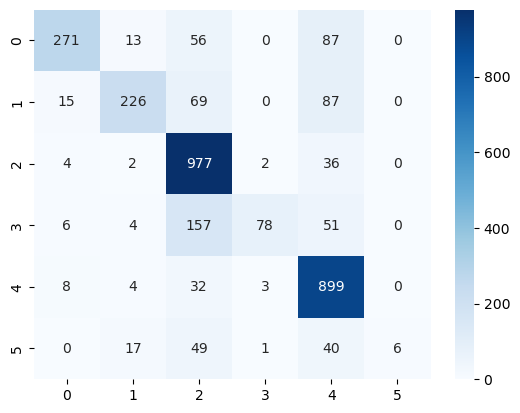

In [61]:
model= MultinomialNB()
model.fit(x_train_bow, y_train)
y_pred = model.predict(x_test_bow)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
confusion_matrix_result = confusion_matrix(y_test, y_pred)
sns.heatmap(confusion_matrix_result, annot=True, fmt='d', cmap='Blues')

In [62]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Accuracy: 0.7678125
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.63      0.74       427
           1       0.85      0.57      0.68       397
           2       0.73      0.96      0.83      1021
           3       0.93      0.26      0.41       296
           4       0.75      0.95      0.84       946
           5       1.00      0.05      0.10       113

    accuracy                           0.77      3200
   macro avg       0.86      0.57      0.60      3200
weighted avg       0.80      0.77      0.74      3200



<Axes: >

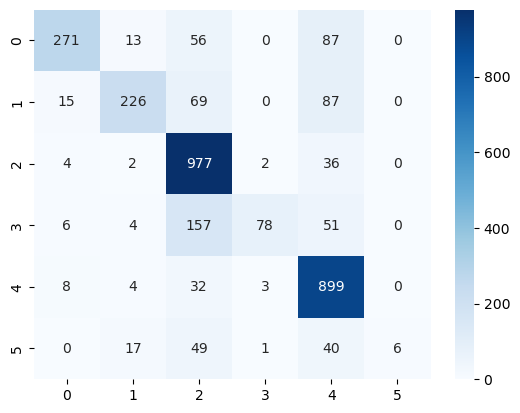

In [63]:
model = MultinomialNB()

model.fit(x_train_bow, y_train)  
y_pred = model.predict(x_test_bow)  

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

confusion_matrix_result = confusion_matrix(y_test, y_pred)
sns.heatmap(confusion_matrix_result, annot=True, fmt='d', cmap='Blues')